# 🏎️ F1 Podium Prediction Model

This notebook builds a machine learning model that predicts whether a driver will **finish on the podium (top 3)** in a race, using the classic Ergast F1 historical dataset.



## 1. Setup & Upload Data

In [ ]:
!pip install -q xgboost scikit-learn pandas numpy matplotlib


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile, io, os

from google.colab import files

print("Please upload your f1.zip file (containing the Ergast CSVs)...")
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]
extract_dir = "f1_data"
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(io.BytesIO(uploaded[zip_name]), 'r') as z:
    z.extractall(extract_dir)

print("Extracted files:", os.listdir(extract_dir))


Please upload your f1.zip file (containing the Ergast CSVs)...


Saving f1.zip to f1.zip
Extracted files: ['status.csv', 'driver_standings.csv', 'results.csv', 'constructors.csv', 'drivers.csv', 'qualifying.csv', 'races.csv', 'constructor_standings.csv', 'pit_stops.csv', 'sprint_results.csv', 'constructor_results.csv', 'circuits.csv', 'lap_times.csv', 'seasons.csv']


## 2. Load Raw Tables

In [ ]:
DATA_DIR = extract_dir

races = pd.read_csv(f"{DATA_DIR}/races.csv")
results = pd.read_csv(f"{DATA_DIR}/results.csv")
drivers = pd.read_csv(f"{DATA_DIR}/drivers.csv")
constructors = pd.read_csv(f"{DATA_DIR}/constructors.csv")
qualifying = pd.read_csv(f"{DATA_DIR}/qualifying.csv")
driver_standings = pd.read_csv(f"{DATA_DIR}/driver_standings.csv")
constructor_standings = pd.read_csv(f"{DATA_DIR}/constructor_standings.csv")
status = pd.read_csv(f"{DATA_DIR}/status.csv")
circuits = pd.read_csv(f"{DATA_DIR}/circuits.csv")

print(races.shape, results.shape, drivers.shape, constructors.shape)


(1125, 18) (26759, 18) (861, 9) (212, 5)


## 3. Build the Base Race-Result Table

We restrict to a modern era (default: 2000 onward) since car/points regulations before that behave quite differently, and qualifying data is sparse in earlier years. You can change `MIN_YEAR` below.

In [ ]:
MIN_YEAR = 2000   # change this if you want more/less history

races_small = races[['raceId', 'year', 'round', 'circuitId', 'date']].copy()
races_small['date'] = pd.to_datetime(races_small['date'], errors='coerce')

df = results.merge(races_small, on='raceId', how='left')
df = df[df['year'] >= MIN_YEAR].copy()

df = df.merge(drivers[['driverId', 'dob', 'nationality', 'code', 'forename', 'surname']],
              on='driverId', how='left')
df = df.merge(constructors[['constructorId', 'name']].rename(columns={'name': 'constructor_name'}),
              on='constructorId', how='left')
df = df.merge(status, on='statusId', how='left')

# numeric cleanup
df['grid'] = pd.to_numeric(df['grid'], errors='coerce')
df['positionOrder'] = pd.to_numeric(df['positionOrder'], errors='coerce')
df['points'] = pd.to_numeric(df['points'], errors='coerce')
df['dob'] = pd.to_datetime(df['dob'], errors='coerce')

# grid == 0 means started from the pit lane -> effectively worse than last on the grid
df.loc[df['grid'] == 0, 'grid'] = df.groupby('raceId')['grid'].transform('max') + 1

# driver age on race day
df['driver_age'] = (df['date'] - df['dob']).dt.days / 365.25

# target: podium finish
df['podium'] = (df['positionOrder'] <= 3).astype(int)

# did-not-finish flag (anything other than "Finished" or "+N Lap(s)" is a retirement)
df['dnf'] = ~(df['status'].eq('Finished') | df['status'].str.startswith('+', na=False))
df['dnf'] = df['dnf'].astype(int)

df = df.sort_values(['date', 'raceId']).reset_index(drop=True)
print(df.shape)
df.head()


(10079, 32)


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,dob,nationality,code,forename,surname,constructor_name,status,driver_age,podium,dnf
0,2931,158,30,6,3,3,1,1,1,10.0,...,1969-01-03,German,MSC,Michael,Schumacher,Ferrari,Finished,31.186858,1,0
1,2932,158,22,6,4,4,2,2,2,6.0,...,1972-05-23,Brazilian,BAR,Rubens,Barrichello,Ferrari,Finished,27.802875,1,0
2,2933,158,23,3,9,11,3,3,3,4.0,...,1975-06-30,German,SCH,Ralf,Schumacher,Williams,Finished,24.700890,1,0
3,2934,158,35,16,22,8,4,4,4,3.0,...,1971-04-09,Canadian,VIL,Jacques,Villeneuve,BAR,Finished,28.925394,0,0
4,2935,158,21,22,11,9,5,5,5,2.0,...,1973-01-14,Italian,FIS,Giancarlo,Fisichella,Benetton,Finished,27.156742,0,0


## 4. Feature Engineering (leakage-safe)

For every feature below we only use information that existed **before** the race started:
- Qualifying position for that race (known before lights out)
- Championship standings **entering** the race (i.e. from the previous round)
- Rolling driver/constructor form over their last N races (shifted by 1 so the current race is never included)
- Driver age, circuit identity

In [ ]:
# --- Qualifying position ---
quali = qualifying[['raceId', 'driverId', 'position']].rename(columns={'position': 'quali_position'})
quali['quali_position'] = pd.to_numeric(quali['quali_position'], errors='coerce')
df = df.merge(quali, on=['raceId', 'driverId'], how='left')
# if a driver has no quali record, fall back to grid position
df['quali_position'] = df['quali_position'].fillna(df['grid'])


In [ ]:
# --- Standings ENTERING the race (i.e. after the previous round of that season) ---
def standings_entering_race(standings_df, id_col):
    s = standings_df.merge(races_small[['raceId', 'year', 'round']], on='raceId', how='left')
    s = s.sort_values(['year', 'round'])
    # shift the round forward by 1 within each season/entity so raceId(round r) sees standings from round r-1
    s['round_next'] = s['round'] + 1
    out = s[['year', 'round_next', id_col, 'points', 'position', 'wins']].rename(
        columns={'round_next': 'round',
                 'points': f'{id_col}_std_points',
                 'position': f'{id_col}_std_position',
                 'wins': f'{id_col}_std_wins'})
    return out

driver_std_entering = standings_entering_race(driver_standings, 'driverId')
constructor_std_entering = standings_entering_race(constructor_standings, 'constructorId')

df = df.merge(driver_std_entering, on=['year', 'round', 'driverId'], how='left')
df = df.merge(constructor_std_entering, on=['year', 'round', 'constructorId'], how='left')

# round 1 of a season -> no prior standings this year: fill with 0 points / worst-case rank / 0 wins
for c in ['driverId_std_points', 'driverId_std_wins', 'constructorId_std_points', 'constructorId_std_wins']:
    df[c] = df[c].fillna(0)
df['driverId_std_position'] = df['driverId_std_position'].fillna(30)
df['constructorId_std_position'] = df['constructorId_std_position'].fillna(30)

df = df.rename(columns={
    'driverId_std_points': 'driver_champ_points',
    'driverId_std_position': 'driver_champ_position',
    'driverId_std_wins': 'driver_champ_wins',
    'constructorId_std_points': 'constructor_champ_points',
    'constructorId_std_position': 'constructor_champ_position',
    'constructorId_std_wins': 'constructor_champ_wins',
})


In [ ]:
# --- Rolling recent form (shifted so the current race is excluded) ---
def add_rolling(frame, group_col, value_col, windows, prefix):
    frame = frame.sort_values(['date', 'raceId'])
    for w in windows:
        frame[f'{prefix}_{value_col}_avg{w}'] = (
            frame.groupby(group_col)[value_col]
                 .transform(lambda s: s.shift(1).rolling(w, min_periods=1).mean())
        )
    return frame

df = add_rolling(df, 'driverId', 'positionOrder', [3, 5, 10], 'driver')
df = add_rolling(df, 'driverId', 'points', [5], 'driver')
df = add_rolling(df, 'driverId', 'podium', [5, 10], 'driver')
df = add_rolling(df, 'driverId', 'dnf', [10], 'driver')
df = add_rolling(df, 'constructorId', 'positionOrder', [5], 'constructor')
df = add_rolling(df, 'constructorId', 'podium', [5], 'constructor')

# a driver's first-ever race in the window will have NaN rolling stats -> fill with sensible defaults
roll_cols = [c for c in df.columns if '_avg' in c]
for c in roll_cols:
    if 'podium' in c or 'dnf' in c:
        df[c] = df[c].fillna(0)
    else:
        df[c] = df[c].fillna(df[c].median())


In [ ]:
# --- Circuit as a category code (tree models handle this natively) ---
df['circuit_code'] = df['circuitId'].astype('category').cat.codes

df['driver_age'] = df['driver_age'].fillna(df['driver_age'].median())

FEATURES = [
    'grid', 'quali_position',
    'driver_champ_points', 'driver_champ_position', 'driver_champ_wins',
    'constructor_champ_points', 'constructor_champ_position', 'constructor_champ_wins',
    'driver_positionOrder_avg3', 'driver_positionOrder_avg5', 'driver_positionOrder_avg10',
    'driver_points_avg5', 'driver_podium_avg5', 'driver_podium_avg10', 'driver_dnf_avg10',
    'constructor_positionOrder_avg5', 'constructor_podium_avg5',
    'driver_age', 'circuit_code',
]
TARGET = 'podium'

model_df = df.dropna(subset=FEATURES + [TARGET]).copy()
print("Rows available for modeling:", len(model_df))
model_df[FEATURES + [TARGET]].describe().T


Rows available for modeling: 10079


,count,mean,std,min,25%,50%,75%,max
grid,10079.0,11.082052,6.160414,1.000000,6.000000,11.000000,16.000000,24.000000
quali_position,10079.0,11.069054,6.153571,1.000000,6.000000,11.000000,16.000000,24.000000
driver_champ_points,10079.0,35.042117,60.317962,0.000000,0.000000,9.000000,40.000000,549.000000
driver_champ_position,10079.0,12.505903,7.855407,1.000000,6.000000,12.000000,18.000000,30.000000
driver_champ_wins,10079.0,0.434964,1.399370,0.000000,0.000000,0.000000,0.000000,18.000000
constructor_champ_points,10079.0,70.501538,116.592876,0.000000,2.000000,20.000000,81.000000,822.000000
constructor_champ_position,10079.0,7.176704,6.411922,1.000000,3.000000,6.000000,9.000000,30.000000
constructor_champ_wins,10079.0,0.873301,2.274199,0.000000,0.000000,0.000000,0.000000,20.000000
driver_positionOrder_avg3,10079.0,11.018950,4.733698,1.000000,7.666667,11.333333,14.666667,24.000000
driver_positionOrder_avg5,10079.0,11.020898,4.400307,1.000000,7.800000,11.400000,14.200000,24.000000


## 5. Time-Based Train/Test Split

We must **not** randomly shuffle rows across time (that would leak the future into training). Instead we train on all seasons except the most recent two, and test on the most recent two seasons — this simulates actually predicting future races.

In [ ]:
TEST_YEARS = 2

max_year = model_df['year'].max()
test_cutoff = max_year - TEST_YEARS + 1

train_df = model_df[model_df['year'] < test_cutoff]
test_df = model_df[model_df['year'] >= test_cutoff]

X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_test, y_test = test_df[FEATURES], test_df[TARGET]

print(f"Train: {X_train.shape}, seasons {train_df['year'].min()}-{train_df['year'].max()}")
print(f"Test:  {X_test.shape}, seasons {test_df['year'].min()}-{test_df['year'].max()}")
print(f"Podium rate - train: {y_train.mean():.3f}, test: {y_test.mean():.3f}")


Train: (9160, 19), seasons 2000-2022
Test:  (919, 19), seasons 2023-2024
Podium rate - train: 0.142, test: 0.150


## 6. Train Models

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, roc_auc_score, confusion_matrix,
                              RocCurveDisplay)

models = {}

# Logistic Regression baseline (needs scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, class_weight='balanced')
log_reg.fit(X_train_scaled, y_train)
models['Logistic Regression'] = (log_reg, X_test_scaled)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=400, max_depth=8, min_samples_leaf=5,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
models['Random Forest'] = (rf, X_test)

# XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(
    n_estimators=400, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss', random_state=42, n_jobs=-1
)
xgb.fit(X_train, y_train)
models['XGBoost'] = (xgb, X_test)

print("Models trained:", list(models.keys()))


Models trained: ['Logistic Regression', 'Random Forest', 'XGBoost']


In [16]:
import joblib

joblib.dump(models["XGBoost"][0], "xgboost_model.pkl")

['xgboost_model.pkl']

## 7. Evaluate Models

In [17]:
for name, (model, X_te) in models.items():
    proba = model.predict_proba(X_te)[:, 1]
    preds = model.predict(X_te)
    auc = roc_auc_score(y_test, proba)
    print(f"\n=== {name} ===")
    print(f"ROC-AUC: {auc:.4f}")
    print(classification_report(y_test, preds, target_names=['No podium', 'Podium']))



=== Logistic Regression ===
ROC-AUC: 0.9279
              precision    recall  f1-score   support

   No podium       0.97      0.82      0.89       781
      Podium       0.46      0.88      0.60       138

    accuracy                           0.83       919
   macro avg       0.72      0.85      0.75       919
weighted avg       0.90      0.83      0.85       919


=== Random Forest ===
ROC-AUC: 0.9328
              precision    recall  f1-score   support

   No podium       0.97      0.87      0.92       781
      Podium       0.53      0.84      0.65       138

    accuracy                           0.87       919
   macro avg       0.75      0.85      0.78       919
weighted avg       0.90      0.87      0.88       919


=== XGBoost ===
ROC-AUC: 0.9177
              precision    recall  f1-score   support

   No podium       0.96      0.90      0.93       781
      Podium       0.58      0.78      0.66       138

    accuracy                           0.88       919
   macro av

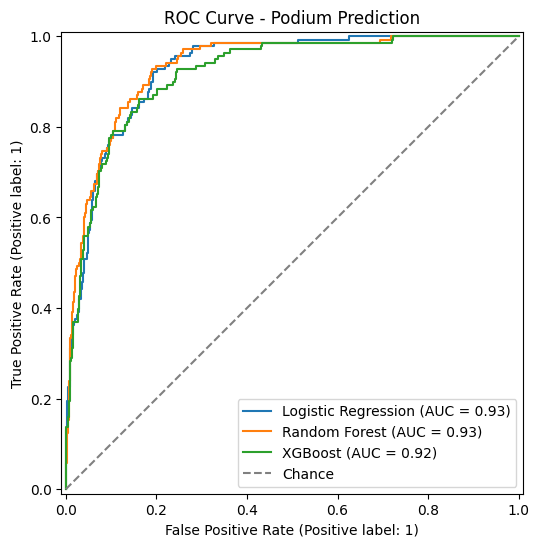

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, (model, X_te) in models.items():
    RocCurveDisplay.from_estimator(model, X_te, y_test, ax=ax, name=name)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
ax.set_title('ROC Curve - Podium Prediction')
ax.legend()
plt.show()


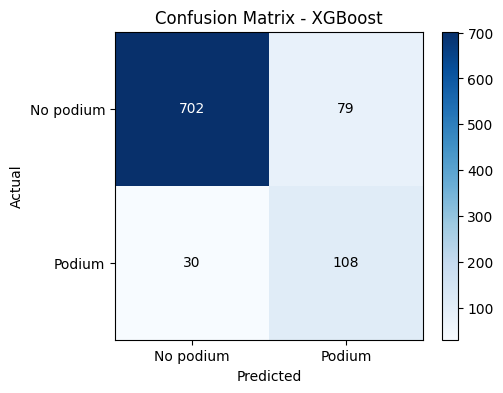

In [ ]:
best_name = 'XGBoost'   # swap to 'Random Forest' or 'Logistic Regression' if you prefer
best_model, best_X_test = models[best_name]

cm = confusion_matrix(y_test, best_model.predict(best_X_test))
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')
plt.title(f'Confusion Matrix - {best_name}')
plt.xticks([0, 1], ['No podium', 'Podium'])
plt.yticks([0, 1], ['No podium', 'Podium'])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center',
                  color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.colorbar()
plt.show()


## 8. Feature Importance

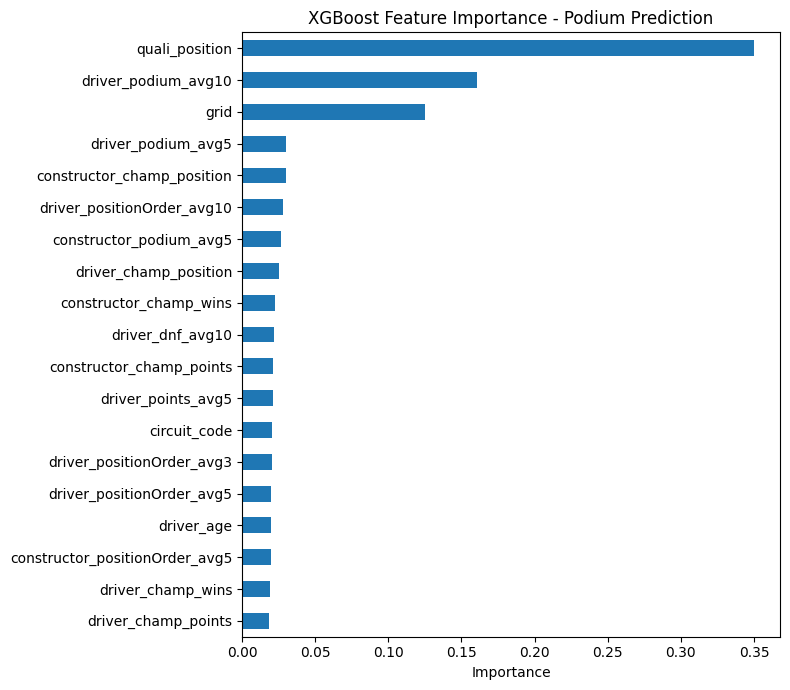

In [ ]:
importances = pd.Series(models['XGBoost'][0].feature_importances_, index=FEATURES)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 7))
importances.plot(kind='barh')
plt.title('XGBoost Feature Importance - Podium Prediction')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


## 9. Predict Podium Probability for an Entire Race Grid

Give this function a `raceId` that's already in the dataset (e.g. a recent race) and it will rank every driver in that race by predicted podium probability, using the best model above.

In [ ]:
def predict_race(race_id, model_name='XGBoost'):
    model, _ = models[model_name]
    race_rows = model_df[model_df['raceId'] == race_id].copy()
    if race_rows.empty:
        print("No data for that raceId in the modeled dataset (check MIN_YEAR / TEST_YEARS).")
        return None

    if model_name == 'Logistic Regression':
        X_race = scaler.transform(race_rows[FEATURES])
    else:
        X_race = race_rows[FEATURES]

    race_rows['podium_probability'] = model.predict_proba(X_race)[:, 1]
    result = race_rows[['forename', 'surname', 'constructor_name', 'grid',
                         'podium_probability', 'positionOrder']].sort_values(
        'podium_probability', ascending=False
    ).rename(columns={'positionOrder': 'actual_finish_position'})
    result.index = range(1, len(result) + 1)
    return result

# Example: pick the most recent race in the test set
example_race_id = test_df.sort_values('date')['raceId'].iloc[-1]
example_race_name = races.loc[races['raceId'] == example_race_id, 'name'].values[0]
example_year = races.loc[races['raceId'] == example_race_id, 'year'].values[0]
print(f"Predicting: {example_year} {example_race_name} (raceId={example_race_id})\n")

predict_race(example_race_id)


Predicting: 2024 Abu Dhabi Grand Prix (raceId=1144)



,forename,surname,constructor_name,grid,podium_probability,actual_finish_position
1,Lando,Norris,McLaren,1,0.963331,1
2,Oscar,Piastri,McLaren,2,0.940011,10
3,Max,Verstappen,Red Bull,4,0.913840,6
4,Carlos,Sainz,Ferrari,3,0.765750,2
5,George,Russell,Mercedes,6,0.238802,5
6,Charles,Leclerc,Ferrari,19,0.134564,3
7,Pierre,Gasly,Alpine F1 Team,5,0.035663,7
8,Lewis,Hamilton,Mercedes,16,0.026654,4
9,Nico,Hülkenberg,Haas F1 Team,7,0.021550,8
10,Sergio,Pérez,Red Bull,10,0.008777,20


## Notes & Next Steps

- **Try a different era:** change `MIN_YEAR` in section 3 to include more or less history.
- **Add features:** pit stop counts/average duration (`pit_stops.csv`), lap-time consistency (`lap_times.csv`), sprint race results, head-to-head teammate qualifying gap, circuit type (street vs permanent), weather (not in this dataset — you'd need to bring your own).
- **Predict a future (not-yet-run) race:** you'd need to construct a row per driver using their *current* rolling form/standings and that race's grid/quali position once qualifying is complete, then call `model.predict_proba` on it directly.
- **Multi-class version:** instead of a binary podium/no-podium target, you could predict exact finishing position (regression) or top-1/top-3/top-10 (multi-class) using the same feature set.
